In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
#data batch size
BATCH_SIZE = 32
#diamensions of img
IMAGE_SIZE = (224, 224)

#get data to train from folder
train_data_dir = "/content/drive/MyDrive/data/dataset"

In [3]:
#split training data into training and validation
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset="training",
                                                         validation_split=0.1,
                                                         seed=42)

Found 7636 files belonging to 7 classes.
Using 6873 files for training.


In [4]:
validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                              batch_size=BATCH_SIZE,
                                                              image_size=IMAGE_SIZE,
                                                              subset="validation",
                                                              validation_split=0.1,
                                                              seed=42)

Found 7636 files belonging to 7 classes.
Using 763 files for validation.


In [5]:
#data feature scaling
from tensorflow.keras.applications.xception import preprocess_input

train_data = train_data.map(lambda x,y:(x/255,y))
validation_data = validation_data.map(lambda x,y:(x/255,y))

In [6]:

#transfer learning(download pretrained model)
pretrained_model = tf.keras.applications.xception.Xception(include_top=False,
                                                           input_shape=(224,224,3),
                                                           weights='imagenet',
                                                           pooling='max')
for layer in pretrained_model.layers:
    layer.trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [8]:
#create model
model = tf.keras.models.Sequential()

model.add(data_augmentation)

model.add(pretrained_model)

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=32, activation='relu'))
model.add(tf.keras.layers.Dense(units=7, activation='softmax'))


In [9]:
#compile model
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = ['accuracy'])

In [10]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [17]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20
)

Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 53s 248ms/step - accuracy: 0.7041 - loss: 0.7838 - val_accuracy: 0.6619 - val_loss: 0.8910
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 79s 236ms/step - accuracy: 0.7071 - loss: 0.7740 - val_accuracy: 0.6527 - val_loss: 0.9060
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 49s 225ms/step - accuracy: 0.7134 - loss: 0.7552 - val_accuracy: 0.6645 - val_loss: 0.9004
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 50s 231ms/step - accuracy: 0.7196 - loss: 0.7498 - val_accuracy: 0.6553 - val_loss: 0.8882
Epoch 5/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 49s 229ms/step - accuracy: 0.7236 - loss: 0.7444 - val_accuracy: 0.6684 - val_loss: 0.8815
Epoch 6/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 50s 230ms/step - accuracy: 0.7205 - loss: 0.7358 - val_accuracy: 0.6645 - val_loss: 0.9083
Epoch 7/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 50s 231ms/step - accuracy: 0.7220 - loss: 0.7341 - val_accuracy: 0.6592 - val_loss: 0.8967
Epoch 8/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 49s 228ms/step - accuracy: 0.7304 - loss: 0

In [18]:
# Unfreeze last 20 layers
for layer in pretrained_model.layers[-20:]:
  layer.trainable = True

In [19]:
#compile model
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = ['accuracy'])

In [20]:
model.fit(train_data, validation_data=validation_data, epochs=5)

Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 77s 308ms/step - accuracy: 0.6675 - loss: 0.8789 - val_accuracy: 0.6723 - val_loss: 0.8926
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 63s 294ms/step - accuracy: 0.7353 - loss: 0.7117 - val_accuracy: 0.6802 - val_loss: 0.8581
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 63s 290ms/step - accuracy: 0.7653 - loss: 0.6302 - val_accuracy: 0.6972 - val_loss: 0.8617
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 63s 294ms/step - accuracy: 0.7806 - loss: 0.5819 - val_accuracy: 0.7326 - val_loss: 0.7678
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 63s 292ms/step - accuracy: 0.8058 - loss: 0.5159 - val_accuracy: 0.7195 - val_loss: 0.8091


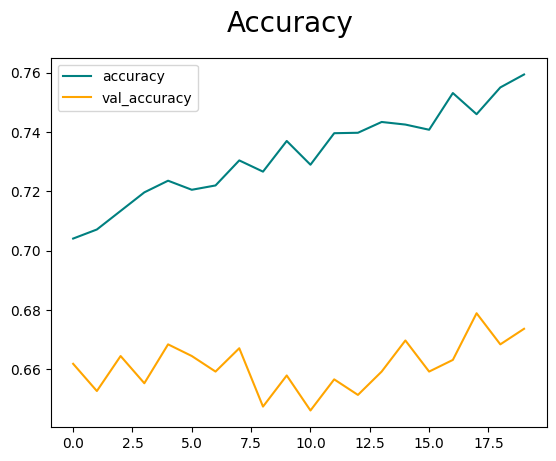

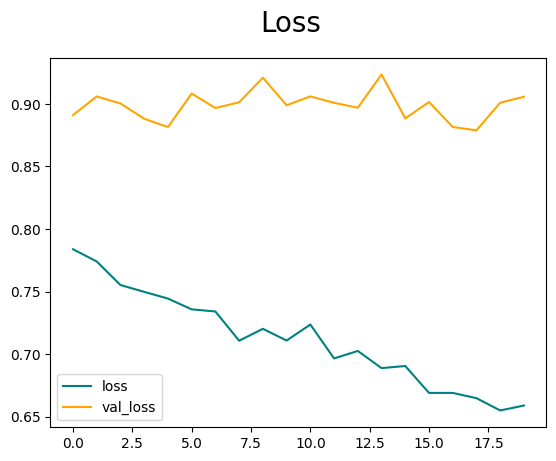

In [21]:
#plot acuuracy vs validation accuracy
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend()
plt.show()

#plot loss vs validation lass
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend()
plt.show()

In [22]:
model.save("model.keras")

In [23]:

print("\nModel saved successfully.")


Model saved successfully.


In [24]:
import pickle

with open("model.pkl", "wb") as file:
  pickle.dump(model, file)

# New Section